In [241]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn # To ignore some warnings from sklearn logistic regression
from sklearn.exceptions import ConvergenceWarning # To avoid logistic regression failing in case of perfect separation

from datetime import datetime
import numpy as np
from scipy.optimize import minimize # minimizing function for AIOLI
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field
import pandas as pd
from sklearn.linear_model import LogisticRegression # for classic logistic regression
from typing import Literal

options={"disp": False} # To not get verbose from minimize function

# Algorithms

## Helper functions for algorithms

First I define some functions that will be used later in all algorithms.

In [242]:
def sig(z):
    """ Sigmoid function that avoids overflow """
    if z < 0:
        return np.exp(z) / (1 + np.exp(z))
    else:
        return 1 / (1 + np.exp(-z))

In [243]:
# NOTE TO DO : put in general algorithm function that if radius == NA then this is not done.
def project_onto_l2_ball(x,radius):
    """ Euclidean projection onto L2 ball"""
    norm = np.linalg.norm(x)
    if norm <= radius:
        return x
    return x * radius/norm

In [244]:
def calculate_OTB(array, method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None, p = 0.5):
    """ Weighted average function
    ----
    Parameters:
        p: Proportion of last observations to average over. Ex p = 0.3 means average over last 30% of observations.
    Methods:
        Suffix averaging: Average over last p percentage of observations.
        Uniform: Average over all iterates equally
        Last iterate: Consider only the last iterate.
        """
    n = len(array)
    # Check p is a proportion
    if p is None:
        p = 0.5
    if not (0 <= p <= 1):
        raise ValueError("p must be between 0 and 1")

    match method:
        case "suffix_averaging":
            i = round((1-p)*n)
            result = np.mean(array[i:], axis=0)
        case "last_iterate":
            last_iterate = n - 1
            result = array[last_iterate]
        case _: # Uniform is default
            result = np.mean(array, axis=0)

    return result

In [245]:
def log_loss(betas,data_x,data_y):
    """ Works for a vector of betas and a whole dataset"""
    return np.sum(np.logaddexp(0,-data_y*np.inner(data_x,betas)))

In [246]:
def generate_y(n,x, betas, linearly_dependent_on_x = True, all_x = True, independent_method = 1,sinusoidal = False, quadratic = False, seed = 40, plot = False):
    y = np.zeros(n)
    prob_y1 = np.zeros(n)
    rng = np.random.default_rng(seed) # Random number generator

    if linearly_dependent_on_x and all_x:
        if sinusoidal:
            for t in range(n):
                prob_y1 = (1/2)*np.sin(np.inner(x[t],betas)) + 1/2
                y[t] = rng.choice([1,-1], size = 1, p = [prob_y1, 1-prob_y1]).item()
        elif quadratic:
            for t in range(n):
                prob_y1 = sig(np.inner(x[t]**2,betas))
                y[t] = rng.choice([1,-1], size = 1, p = [prob_y1, 1-prob_y1]).item()
        else:   # following sigmoid function. Default choice
            prob_y1 = [sig(np.inner(x_t,betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]
    elif linearly_dependent_on_x:
        x1_x2 = x[:,0:2]
        for t in range(n):
            prob_y1 = sig(np.inner(x1_x2[t],betas[0:2]))
            y[t] = rng.choice([1,-1], size = 1, p = [prob_y1, 1-prob_y1]).item()
    elif sinusoidal:
        for t in range(n):
            prob_y1 = np.sin(np.inner(x[t],betas))
            y[t] = rng.choice([1,-1], size = 1, p = [prob_y1, 1-prob_y1]).item()
    else:
        if independent_method == 1:
            prob_y1 = rng.uniform(0.1,0.9)
            y = rng.choice([1,-1], size = n, p = [prob_y1, 1-prob_y1])
        if independent_method == 2:
            for t in range(n):
                prob_y1 = sig(np.inner((1/x[t]),betas))
                y[t] = rng.choice([1,-1], size = 1, p = [prob_y1, 1-prob_y1]).item()
        if independent_method == 3:
            # Unbalanced classes
            prob_y1 = 0.8
            y = rng.choice([1,-1], size = n, p = [prob_y1, 1-prob_y1])
    # Graphs
    if plot:
        for i in range(x.shape[1]):
            sns.scatterplot(x = x[:,i].flatten(), y = prob_y1)
            plt.title(f"P(Y=1) over x{i}")
            plt.show()

    return np.array(y)

In [247]:
def generate_x(n,d, correlated = True, means = None, sds = None, highly_correlated = True, seed = 40, standardized = False):
    rng = np.random.default_rng(seed) # Random number generator
    x = []

    if sds is None:
        sds = rng.uniform(0.1,4,d)
    if means is None:
        means = [rng.normal(1,sd,1).item() for sd in sds]
    # Put variances in covariance matrix
    cov = np.diag(sds**2)

    if not correlated:
        x = rng.multivariate_normal(means,cov, size = n)
    if correlated:
        # Create off diagonal, triangular matrix
        off_diag = np.triu(rng.uniform(0,2, size = (d,d)))
        cov = cov + off_diag + off_diag.T
        x = rng.multivariate_normal(means,cov, size = n)
        if highly_correlated and d == 3:
            x1 = generate_x(n,1)
            x2 = x1 + rng.normal(2,1)
            x3 = x1 + x2
            x = np.concatenate((x1,x2,x3), axis = 1)

    if standardized:
        standardized_x = (x - np.mean(x, axis=0) ) / np.std(x, axis=0)
        x = standardized_x
    return x


## Online Gradient Descent

In [248]:
def online_gd(n, d, data_y, data_x, B, OTB_method = None, OTB_average_proportion = None):
    """Online gradient descent
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B: float
        Radius of the L2 ball constraint for the parameter vector beta
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.now()

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.

    loss = np.zeros(n)
    G = 1 # Max gradient
    eta = 1
    gradient = np.zeros(d)
    y_hat = np.zeros(n)

    for t in range(n):
        # Observe context vector for this round
        xt = data_x[t]

        # Update parameter (beta)
        if t == 0:
            beta_tilde = np.zeros(d)
        else:
            beta_tilde = betas[t-1] - eta*gradient

        # Euclidean projection of beta onto the L2 ball
        #betas[t] = project_onto_l2_ball(beta_tilde,B)
        betas[t] = beta_tilde

        # Issue prediction
        y_hat[t] = sig(np.inner(betas[t],xt))

        # Observe true y from the data
        yt = data_y[t]

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        # update maximum gradient
        G = np.max([G,np.linalg.norm(gradient)**2])

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Recalculate eta
        eta = 1 / np.sqrt((t+1) * G) # Here t+1 simply because python initializes t to 0


    # Store endtime
    end_time = datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas,
        "predictions": y_hat
    }


### Testing ODG

In [249]:
#ogd = online_gd(n = 40,d = 3,data_y = y,data_x = x,B = 40)

## AIOLI

In [250]:
class AIOLI:
    def __init__(self):
        self.first_sum  = []
        self.etas_gradients = []
        self.x0 = [] # Initializer for minimizing algorithm
        self.reg_lambda = 0
        self.train_size = 0
        self.d = 0
        self.n = 0

    # Define function to minimize for AIOLI
    @staticmethod # Because I dont use the self
    def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
        l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
        # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
        result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
        return result

    def new_point_loss(self,X,Y, OTB_method):
        convergence_new = 0
        beta_hat = np.zeros((self.train_size,self.d))
        first_sum  = np.zeros(self.d)
        etas_gradients = np.zeros((self.d,self.d))
        for t in range(self.train_size):
            # Minimize using data up until t-1
            result = minimize(self.parameter_function_AIOLI, self.x0, method = "l-bfgs-b", args=(X, self.reg_lambda,first_sum, etas_gradients))
            beta_hat[t] = result.x
            convergence_new += result.success
            # Update minimization elements for next round
            first_sum += self.first_sum[t]
            etas_gradients += self.etas_gradients[t]

        # Get OTB
        big_beta = calculate_OTB(beta_hat, OTB_method)

        # Suffer loss
        loss_point = np.logaddexp(0,-Y*np.inner(X,big_beta))

        return loss_point

    def new_data_loss(self,new_data_x,new_data_y, OTB_method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None):
        start_time = datetime.now()
        new_losses = [ self.new_point_loss(X,Y, OTB_method) for (X,Y) in zip(new_data_x,new_data_y) ] # Zip pairs the rows of x and y
        end_time = datetime.now()
        return{
                "runtime" : (end_time - start_time).total_seconds(),
                "loss" : sum(new_losses)
            }


    def fit(self, data_y, data_x, B, X, OTB_method = None, OTB_average_proportion = None, minimize_method = "l-bfgs-b"):
        """AIOLI
        This is the function to run AIOLI.

        Parameters
        ---------
        data_y : ndarray
            Vector with outcome(y) values. Dimensions: n x 1
        data_x: ndarray
            Array with independent variables. Dimensions: n x d
        B: float
            Radius of the L2 ball constraint for the parameter vector beta
        X: float
            Radius of the L2 ball constraint for the feature vector x"""
        # Record start time
        start_time = datetime.now()

        # Get data dimensions
        self.n = data_x.shape[0]
        n = self.n
        self.d = data_x.shape[1]
        d = self.d
        self.x0 = np.zeros(d) # Initializer for minimizing algorithm
        self.train_size = n
        # Initialize vectors for storage
        betas = np.zeros((n, d))
        ys = np.zeros(n)
        y_hats = np.zeros(n)
        loss = np.zeros(n)
        etas = np.zeros(n)
        gradients = np.zeros((n, d))
        self.reg_lambda = 1 / (B**2)

        # Keep sums for loss functions
        self.first_sum  = np.zeros((n, d))
        self.etas_gradients = np.zeros((n,d,d))
        first_sum  = np.zeros(d)
        etas_gradients = np.zeros((d,d))

        # Track convergence
        convergence = 0
        minimizer_gradient = 0

        # Run Algorithm
        for t in range(n):
            # Get context vector
            xt = data_x[t]

            # Update beta parameter
            # noinspection PyTypeChecker # This is to avoid the underlining which
            if t == 0: # Initialize to 0 for first round
                beta_tilde = np.zeros(d)
            else:
                result = minimize(self.parameter_function_AIOLI,
                                  np.zeros(d),
                                  method = minimize_method,
                                  args=(xt, self.reg_lambda,first_sum, etas_gradients),
                                  options = {"maxiter":100000}
                                  )
                betas[t] = result.x
                convergence += result.success
                minimizer_gradient += np.linalg.norm(result.jac)

            # Project beta onto set
            #betas[t] = project_onto_l2_ball(beta_tilde,B)
            #betas[t] = self.x0

            # Generate prediction
            y_hats[t] = np.inner(xt,betas[t])

            # Observe true y from data
            ys[t] = data_y[t]

             # Compute gradient
            gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))

            # Estimate eta
            etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)

            # Suffer loss
            loss[t] = np.logaddexp(0,-ys[t]*np.inner(xt,betas[t]))

            # Compute elements for AIOLI loss function

            fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
            eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
            self.first_sum[t] = fs
            self.etas_gradients[t] = eg
            first_sum += fs
            etas_gradients += eg
            # Here this is separated and a bit reiterative because else the way the vector is stored messes up with the function. I tried multiple ways and this seemed the best one.
        # for loop ends

        # Get Batch estimate
        betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

        # Get Batch estimate loss
        loss_OTB = log_loss(betas_OTB,data_x, data_y)

        end_time = datetime.now()

        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "Total_Loss" : loss_OTB,
            "Online_Loss" : sum(loss),
            "Batch_estimate": betas_OTB,
            "All_Betas": betas,
            "convergence" : convergence,
            "minimizer_gradient" : minimizer_gradient
        }



### Testing AIOLI

In [251]:
x = generate_x(15,3)
betas = np.random.uniform(0.1,5,3)
y = generate_y(15,x,betas = betas)

x_train = x[:10]
y_train = y[:10]
x_test = x[10:]
y_test = y[10:]

### AIOLI convergence check

In [252]:
aioli_model = AIOLI()
aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 40, minimize_method = "l-bfgs-b")
aioli_results

{'runtime': 0.098523,
 'Total_Loss': np.float64(12.941174783771025),
 'Online_Loss': np.float64(1.8407362887948284),
 'Batch_estimate': array([-87.65439536, 101.91354316,  14.25971506]),
 'All_Betas': array([[   0.        ,    0.        ,    0.        ],
        [ -85.68643919,   87.76368912,    2.07709281],
        [ -86.23062651,   88.40155721,    2.17075996],
        [-139.72480164,  152.40850935,   12.68506295],
        [ 154.97488579, -144.87700714,   10.09162851],
        [ -94.53507048,   97.15783479,    2.62299822],
        [-114.66360844,  120.38134931,    5.7228865 ],
        [-180.1736248 ,  214.20209496,   34.02916412],
        [-176.59633768,  209.07809767,   32.4813074 ],
        [-153.90833067,  194.61930634,   40.71625014]]),
 'convergence': 9,
 'minimizer_gradient': np.float64(0.00039591941840513454)}

In [253]:
minimization_methods = ["l-bfgs-b",'bfgs',"CG"]

for method in minimization_methods:
    aioli_model = AIOLI()
    aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 40, minimize_method = method)
    print(f"Method: {method}")
    print(f"convergence: {aioli_results["convergence"]}")
    print(f"minimizer_gradient: {aioli_results["minimizer_gradient"]}")
    print(f"Online loss: {aioli_results["Online_Loss"]}")


Method: l-bfgs-b
convergence: 9
minimizer_gradient: 0.00039591941840513454
Online loss: 1.8407362887948284
Method: bfgs
convergence: 9
minimizer_gradient: 7.337870577274077e-05
Online loss: 1.8407288531230965
Method: CG
convergence: 8
minimizer_gradient: 9.102680312853132e-05
Online loss: 1.8407406927975576


In [254]:
aioli_model.new_data_loss(new_data_x = x_test, new_data_y = y_test, OTB_method = "uniform")

{'runtime': 0.219639, 'loss': np.float64(0.37237229450645803)}

## Ada Grad

In [255]:
# OJO STILL HAVE TO CODE THIS. the code is just OGD.
def online_AdaGrad(n, d, data_y, data_x, B, OTB_method = None, OTB_average_proportion = None):
    """Online Adaptive Gradient
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B: float
        Radius of the L2 ball constraint for the parameter vector beta
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.now()

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.

    loss = np.zeros(n)
    G = 1 # Max gradient
    eta = 1
    gradient = np.zeros(d)

    for t in range(n):
        # Observe context vector for this round
        xt = data_x[t]

        # Update parameter (beta)
        if t == 0:
            beta_tilde = np.zeros(d)
        else:
            beta_tilde = betas[t-1] - eta*gradient

        # Euclidean projection of beta onto the L2 ball
        #betas[t] = project_onto_l2_ball(beta_tilde,B)
        betas[t] = beta_tilde

        # Issue prediction
        #y_hat = sig(np.inner(betas[t],xt)) commented out because its never used so there's no need to calculate it

        # Observe true y from the data
        yt = data_y[t]

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        # update maximum gradient
        G = np.max([G,np.linalg.norm(gradient)**2])

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Recalculate eta
        eta = 1 / np.sqrt((t+1) * G) # Here t+1 simply because python initializes t to 0


    # Store endtime
    end_time = datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas
    }


## Logistic Regression

In [256]:
def classic_logistic_regression(data_x, data_y):
    # Using safe implementation where if data is perfectly separable, then it's just fit minimizing the logistic loss.
    start_time = datetime.now()

    logreg = LogisticRegression(penalty=None, fit_intercept=False, max_iter=10000)

    try:
        logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        # Single class case: fit manually using scipy minimize on the logistic loss
        def logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores))

        result = minimize(logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Logistic regression was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [257]:
# def classic_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty=None, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Ridge Logistic Regression

In [258]:
def ridge_logistic_regression(data_x, data_y, reg_lambda=1.0):
    start_time = datetime.now()

    logreg = LogisticRegression(penalty='l2', C=1/reg_lambda, fit_intercept=False, max_iter=10000, random_state=1)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def ridge_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.linalg.norm(b)**2

        result = minimize(ridge_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Ridge LG was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [259]:
# def ridge_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty="l2", random_state=1, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Sample Minmax Predictor (SMP)

In [260]:
class sample_minmax_predictor():
    def __init__(self,data_x, data_y):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = sig(1*np.inner(beta_hat_y1,new_x)) / ( sig(np.inner(beta_hat_y1,new_x)*1) + sig(np.inner(beta_hat_y_1,new_x)*(-1)) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.now()
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : sum(new_losses)
        }


### Testing SMP

In [261]:
smp = sample_minmax_predictor(x_train, y_train)
smp.get_new_loss(x_test, y_test)

{'runtime': 0.050731, 'loss': np.float64(0.7000494007963665)}

# Functions for simulations

## Data class for specifying simulation configuration

In [262]:
@dataclass
class SimulationConfig:
    # Default is well specified
    runs: int = 5
    n: int = 200
    d: int = 3
    betas: list = field(default_factory=lambda: [2,0.1,-4.2]) # This is to create a new list every time.
    x_means: list = field(default_factory=lambda: [2,2,1])
    # These values of betas and x_means guarantee a P(Y=1) = 0.5, hence balanced classes.
    B: int = 40
    X: int = 10
    test_ratio: float = 0.3
    minimize_method: str = "l-bfgs-b"
    sinusoidal: bool = False
    quadratic: bool = False

## Function to run simulations and get results

In [263]:
def run_simulation(cfg: SimulationConfig):
    runs = cfg.runs
    n = cfg.n
    d = cfg.d
    betas = cfg.betas
    x_means = cfg.x_means
    B = cfg.B
    X = cfg.X
    test_ratio = cfg.test_ratio
    minimize_method = cfg.minimize_method
    sinusoidal_bool = cfg.sinusoidal
    quadratic_bool = cfg.quadratic

    results_all = []
    test_set_results = []

    for i in range(runs):

        test_size = round(n * test_ratio)
        train_size = n - test_size

        x = generate_x(n, d, means = x_means, seed = 40 + i)
        y = generate_y(n, x, betas, seed = 40 + i, sinusoidal = sinusoidal_bool, quadratic = quadratic_bool)

        # Split train/test
        x_train, y_train, x_test, y_test = x[:train_size], y[:train_size], x[train_size:], y[train_size:]

        # Run algorithms
        ogd = online_gd(n=train_size, d=d, data_y=y_train, data_x=x_train, B=B)
        aioli_model = AIOLI()
        ai = aioli_model.fit(data_y=y_train, data_x=x_train, X=X, B=B, minimize_method = minimize_method)
        classic_lg = classic_logistic_regression(data_x=x_train, data_y=y_train)
        ridge_lg = ridge_logistic_regression(data_x=x_train, data_y=y_train)
        smp = sample_minmax_predictor(x_train, y_train)

        # OTB estimates
        OGD_OTB_uniform = calculate_OTB(ogd["All_Betas"], "uniform")
        OGD_OTB_Suffix  = calculate_OTB(ogd["All_Betas"], "suffix_averaging")
        OGD_OTB_lastit  = calculate_OTB(ogd["All_Betas"], "last_iterate")

        # Training losses
        loss_OGD_Suffix = log_loss(OGD_OTB_Suffix, x_train, y_train)
        loss_OGD_lastit = log_loss(OGD_OTB_lastit, x_train, y_train)

        # TRAINING RESULTS

        algorithms_train = {
            "OGD_uniform": {
                "runtime": ogd["runtime"],
                "loss (trainset)": ogd["Total_Loss"],
                "online_loss": ogd["Online_Loss"],
                "betas": ogd["Batch_estimate"]
            },
            "OGD_Suffix": {
                "loss (trainset)": loss_OGD_Suffix,
                "betas": OGD_OTB_Suffix
            },
            "OGD_Last_iterate": {
                "loss (trainset)": loss_OGD_lastit,
                "betas": OGD_OTB_lastit
            },
            "AIOLI_uniform": {
                "runtime": ai["runtime"],
                "loss (trainset)": ai["Total_Loss"],
                "online_loss": ai["Online_Loss"],
                "betas": ai["Batch_estimate"],
                "convergence": ai["convergence"],
                "minimizer_gradient": ai["minimizer_gradient"]
            },
            "Classical_LG": {
                "runtime": classic_lg["runtime"],
                "loss (trainset)": classic_lg["Total_Loss"],
                "betas": classic_lg["Batch_estimate"]
            },
            "Ridge_LG": {
                "runtime": ridge_lg["runtime"],
                "loss (trainset)": ridge_lg["Total_Loss"],
                "betas": ridge_lg["Batch_estimate"]
            }
        }

        for name, metrics in algorithms_train.items():
            results_all.append({"algorithm": name, **metrics})

        # TEST RESULTS

        loss_OGD_uniform_test = log_loss(OGD_OTB_uniform, x_test, y_test)
        loss_OGD_Suffix_test  = log_loss(OGD_OTB_Suffix,  x_test, y_test)
        loss_OGD_lastit_test  = log_loss(OGD_OTB_lastit,  x_test, y_test)

        loss_AIOLI_uniform_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
        loss_AIOLI_Suffix_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"]
        loss_AIOLI_lastit_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"]

        loss_LG_test = log_loss(classic_lg["Batch_estimate"], x_test, y_test)
        loss_LG_Ridge_test = log_loss(ridge_lg["Batch_estimate"],   x_test, y_test)

        smp_result = smp.get_new_loss(x_test, y_test)

        algorithms_test = {
            "OGD_uniform": {"loss (testset)": loss_OGD_uniform_test},
            "OGD_Suffix":  {"loss (testset)": loss_OGD_Suffix_test},
            "OGD_Last_iterate": {"loss (testset)": loss_OGD_lastit_test},
            "AIOLI_uniform": {"loss (testset)": loss_AIOLI_uniform_test},
            "AIOLI_Suffix":  {"loss (testset)": loss_AIOLI_Suffix_test},
            "AIOLI_lastit":  {"loss (testset)": loss_AIOLI_lastit_test},
            "Classical_LG":  {"loss (testset)": loss_LG_test},
            "Ridge_LG":      {"loss (testset)": loss_LG_Ridge_test},
            "SMP":      {"loss (testset)": smp_result["loss"]}
        }

        for name, metrics in algorithms_test.items():
             test_set_results.append({
                "run": i,
                "algorithm": name,
                **metrics
            })
        print(f"Run {i} finished")

    return {
        "final_results": pd.DataFrame(results_all),
        "test_results": pd.DataFrame(test_set_results)
    }


## Function for printing results

In [264]:
def print_results(results):
    summary_train = results["final_results"].groupby("algorithm")[["runtime", "loss (trainset)", "online_loss", "betas"]].mean()
    summary_train["betas"] = summary_train["betas"].apply(lambda array: np.round(array, 3))
    summary_test = results["test_results"].groupby("algorithm")[["loss (testset)"]].mean()
    display(summary_train)
    display(summary_test)

## Function for graphing loss over runs

In [265]:
def plot_results(results):
    test_results = results["test_results"]
    test_results

    sns.lineplot(x = test_results["run"], y = test_results["loss (testset)"], hue = test_results["algorithm"])


# Experiments

## Balanced

### X means and betas for balanced data $P(Y=1) = 0.5)$

In [266]:
# Balanced
bs_balanced = [2,0.1,-4.2]
xs_balanced = [2,2,1]
print(np.inner(bs_balanced,xs_balanced))
print(sig(np.inner(bs_balanced,xs_balanced)))
print((1/2)*np.sin(np.inner(xs_balanced,bs_balanced)) + 1/2)

0.0
0.5
0.5


In [267]:
# Balanced High dimensional (25 variables)
bs_hd_balanced = [2,0.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7]

xs_hd_balanced = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]


print(len(bs_hd_balanced), len(xs_hd_balanced))
print(np.inner(bs_hd_balanced,xs_hd_balanced))
print(sig(np.inner(bs_hd_balanced,xs_hd_balanced)))
print((1/2)*np.sin(np.inner(xs_hd_balanced,bs_hd_balanced)) + 1/2)

25 25
-0.02000000000000135
0.49500016665999996
0.4900006666533328


### Experiments

In [268]:
well_specified = SimulationConfig(
    runs = 10,
    n = 100,
    d = 3,
    betas= bs_balanced,
    x_means= xs_balanced
)

well_specified_result = run_simulation(well_specified)
print_results(well_specified_result)

Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished
Run 5 finished
Run 6 finished
Run 7 finished
Run 8 finished
Run 9 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.385592,71.648765,10.490642,"[11.437, -44.28, -32.843]"
Classical_LG,0.005707,3.610190,NaN,"[-1.238, -2.967, -4.205]"
OGD_Last_iterate,NaN,5.385771,NaN,"[-0.259, -0.775, -1.034]"
OGD_Suffix,NaN,5.525919,NaN,"[-0.242, -0.758, -1.0]"
OGD_uniform,0.002206,5.830135,6.739002,"[-0.208, -0.713, -0.921]"
Ridge_LG,0.003126,4.774487,NaN,"[-0.318, -0.924, -1.242]"


,loss (testset)
algorithm,
AIOLI_Suffix,1.734089
AIOLI_lastit,4.811889
AIOLI_uniform,1.769527
Classical_LG,1.699612
OGD_Last_iterate,1.996294
OGD_Suffix,1.996293
OGD_uniform,2.091330
Ridge_LG,1.874781
SMP,2.160542


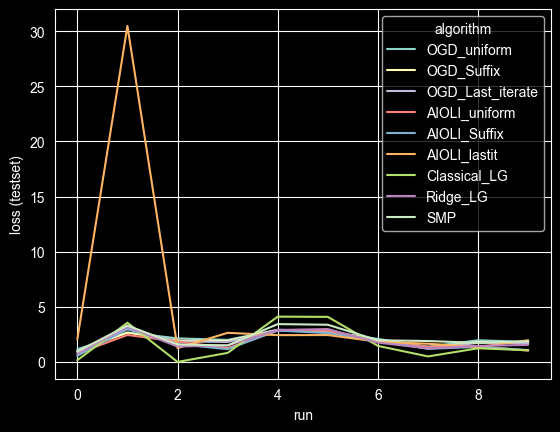

In [269]:
plot_results(well_specified_result)

In [270]:
high_dimensional = SimulationConfig(
    runs = 10,
    n = 20,
    d = 25,
    betas= bs_hd_balanced,
    x_means= xs_hd_balanced
)

high_dimensional_result = run_simulation(high_dimensional)
print_results(high_dimensional_result)

Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished
Run 5 finished
Run 6 finished
Run 7 finished
Run 8 finished
Run 9 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.603022,242.615107,9.665104,"[26.006, 6.596, -16.629, 12.441, 8.428, -3.359..."
Classical_LG,0.002904,0.000376,NaN,"[0.88, 0.324, -0.489, 0.303, 0.363, -0.147, -0..."
OGD_Last_iterate,NaN,8.005064,NaN,"[0.154, 0.025, -0.078, 0.101, 0.136, 0.033, -0..."
OGD_Suffix,NaN,6.896670,NaN,"[0.127, 0.007, -0.072, 0.092, 0.125, 0.038, -0..."
OGD_uniform,0.000305,16.504879,27.232942,"[0.101, -0.013, -0.04, 0.04, 0.109, 0.095, -0...."
Ridge_LG,0.004103,0.293935,NaN,"[0.28, 0.105, -0.158, 0.11, 0.104, -0.035, -0...."


,loss (testset)
algorithm,
AIOLI_Suffix,4.120900
AIOLI_lastit,4.098817
AIOLI_uniform,4.136550
Classical_LG,7.148387
OGD_Last_iterate,5.087829
OGD_Suffix,4.369243
OGD_uniform,8.084532
Ridge_LG,3.321264
SMP,4.158882


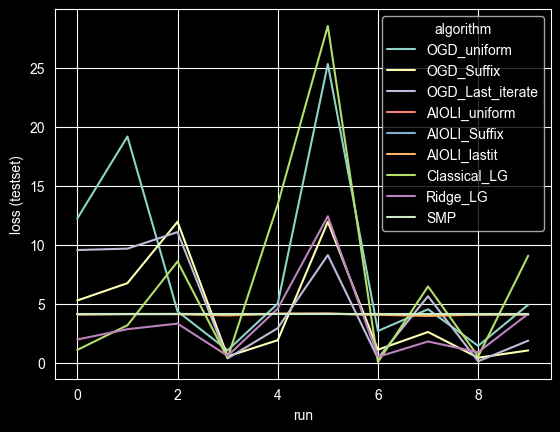

In [271]:
plot_results(high_dimensional_result)

In [272]:
high_dimensionality = SimulationConfig(
    runs = 5,
    n = 50,
    d = 25,
    betas= bs_hd_balanced,
    x_means= xs_hd_balanced
)

high_dimensionality_result = run_simulation(high_dimensionality)
print_results(high_dimensionality_result)

Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,3.956566,939.052924,23.091074,"[38.336, 37.163, -16.308, 37.505, 6.321, -22.3..."
Classical_LG,0.002566,0.001283,NaN,"[1.581, 0.879, -1.311, 0.864, -0.036, -0.223, ..."
OGD_Last_iterate,NaN,16.416314,NaN,"[0.228, 0.041, -0.16, 0.127, 0.118, 0.029, -0...."
OGD_Suffix,NaN,16.334421,NaN,"[0.205, 0.032, -0.129, 0.131, 0.148, 0.051, -0..."
OGD_uniform,0.001079,25.604094,47.636903,"[0.168, 0.021, -0.076, 0.11, 0.139, 0.057, -0...."
Ridge_LG,0.003442,0.982735,NaN,"[0.391, 0.216, -0.3, 0.218, 0.005, -0.104, -0...."


,loss (testset)
algorithm,
AIOLI_Suffix,9.336437
AIOLI_lastit,8.470697
AIOLI_uniform,9.757954
Classical_LG,18.210434
OGD_Last_iterate,7.692456
OGD_Suffix,8.293304
OGD_uniform,12.348375
Ridge_LG,5.272035
SMP,10.397206


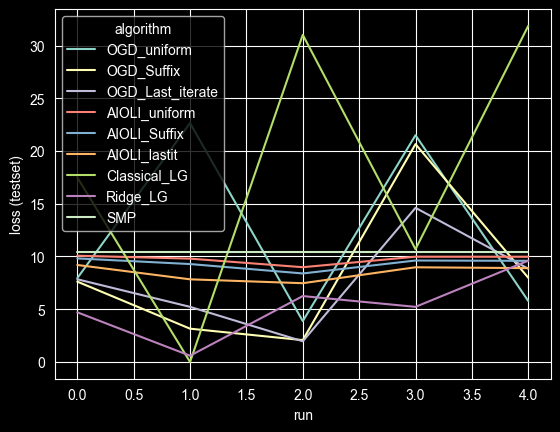

In [301]:
plot_results(high_dimensionality_result)

In [273]:
sinusoidal = SimulationConfig(
    runs = 10,
    n = 100,
    d = 3,
    betas= bs_balanced,
    x_means= xs_balanced,
    sinusoidal = True
)

sinusoidal_result = run_simulation(sinusoidal)
print_results(sinusoidal_result)

Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished
Run 5 finished
Run 6 finished
Run 7 finished
Run 8 finished
Run 9 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.188986,1206.222551,225.430757,"[11.571, -14.982, -3.411]"
Classical_LG,0.001446,47.905175,NaN,"[-0.005, -0.005, -0.009]"
OGD_Last_iterate,NaN,54.194466,NaN,"[0.114, -0.133, -0.019]"
OGD_Suffix,NaN,51.564552,NaN,"[0.132, -0.144, -0.012]"
OGD_uniform,0.001001,54.954942,64.909294,"[0.123, -0.19, -0.068]"
Ridge_LG,0.001195,47.905623,NaN,"[-0.007, -0.002, -0.009]"


,loss (testset)
algorithm,
AIOLI_Suffix,37.780911
AIOLI_lastit,41.967295
AIOLI_uniform,37.720373
Classical_LG,21.196300
OGD_Last_iterate,21.843374
OGD_Suffix,20.043789
OGD_uniform,21.411690
Ridge_LG,21.185530
SMP,21.171032


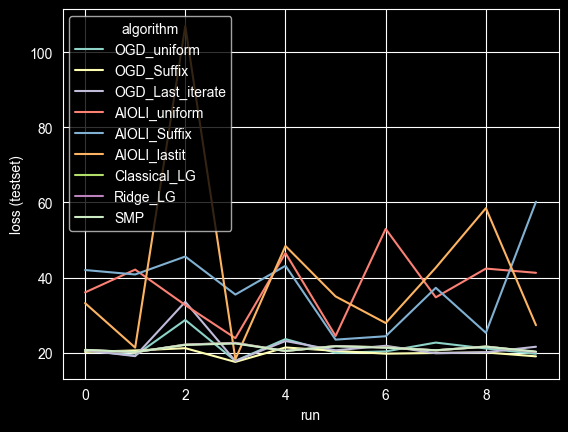

In [302]:
plot_results(sinusoidal_result)

In [274]:
quadratic = SimulationConfig(
    runs = 10,
    n = 100,
    d = 3,
    betas= bs_balanced,
    x_means= xs_balanced,
    quadratic = True
)

quadratic_result = run_simulation(quadratic)
print_results(quadratic_result)

Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished
Run 5 finished
Run 6 finished
Run 7 finished
Run 8 finished
Run 9 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.222322,695.648391,555.891189,"[70.501, -68.922, 1.58]"
Classical_LG,0.002949,21.449498,NaN,"[1.432, -1.384, 0.048]"
OGD_Last_iterate,NaN,28.666524,NaN,"[0.541, -0.43, 0.112]"
OGD_Suffix,NaN,28.101098,NaN,"[0.5, -0.446, 0.054]"
OGD_uniform,0.000869,28.799137,43.613699,"[0.457, -0.398, 0.058]"
Ridge_LG,0.001915,22.021674,NaN,"[1.077, -1.026, 0.051]"


,loss (testset)
algorithm,
AIOLI_Suffix,204.622112
AIOLI_lastit,100.881136
AIOLI_uniform,165.495154
Classical_LG,8.976031
OGD_Last_iterate,14.724804
OGD_Suffix,12.719247
OGD_uniform,13.363282
Ridge_LG,9.170136
SMP,9.500507


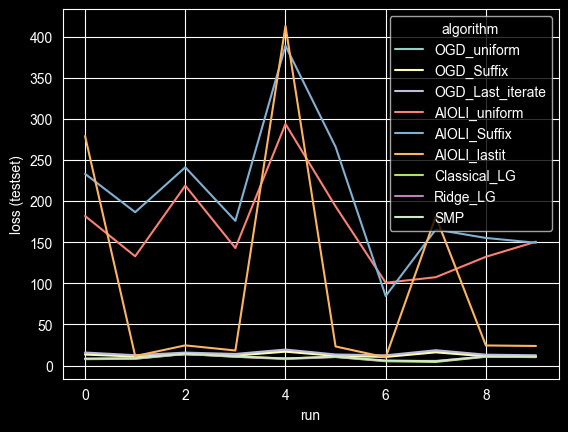

In [303]:
plot_results(quadratic_result)

## Unbalanced

### X means and betas for unbalanced data $P(Y=1)$ -> 1 or 0)


In [275]:

# Unbalanced
bs_unbalanced = [1.5,0.1,-4.2]
xs_unbalanced = [2,2,1]
print(np.inner(bs_unbalanced,xs_unbalanced))
print(sig(np.inner(bs_unbalanced,xs_unbalanced)))
print((1/2)*np.sin(np.inner(xs_unbalanced,bs_unbalanced)) + 1/2)

# High dimensional

-1.0
0.2689414213699951
0.07926450759605175


In [276]:
# Unbalanced High dimensional (25 variables)
bs_hd_unbalanced = [2,1.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7]

xs_hd_unbalanced = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]


print(len(bs_hd_unbalanced), len(xs_hd_unbalanced))
print(np.inner(bs_hd_unbalanced,xs_hd_unbalanced))
print(sig(np.inner(bs_hd_unbalanced,xs_hd_unbalanced)))
print((1/2)*np.sin(np.inner(xs_hd_unbalanced,bs_hd_unbalanced)) + 1/2)

25 25
2.08
0.8889440332885924
0.9365664897537582


### Experiments

In [277]:
well_specified_unbalanced = SimulationConfig(
    betas= bs_unbalanced,
    x_means= xs_unbalanced
)

well_specified_unbalanced_result = run_simulation(well_specified_unbalanced)
print_results(well_specified_unbalanced_result)

Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.353330,57.964891,14.084286,"[4.287, -34.973, -30.686]"
Classical_LG,0.002091,5.948608,NaN,"[-0.613, -3.764, -4.377]"
OGD_Last_iterate,NaN,8.592264,NaN,"[-0.326, -0.802, -1.128]"
OGD_Suffix,NaN,8.770247,NaN,"[-0.312, -0.775, -1.088]"
OGD_uniform,0.001530,9.202353,10.324361,"[-0.286, -0.727, -1.013]"
Ridge_LG,0.001672,7.281497,NaN,"[-0.364, -1.093, -1.457]"


,loss (testset)
algorithm,
AIOLI_Suffix,4.028037
AIOLI_lastit,2.751410
AIOLI_uniform,3.956624
Classical_LG,3.440077
OGD_Last_iterate,3.841458
OGD_Suffix,3.956073
OGD_uniform,4.074436
Ridge_LG,3.571260
SMP,3.521182


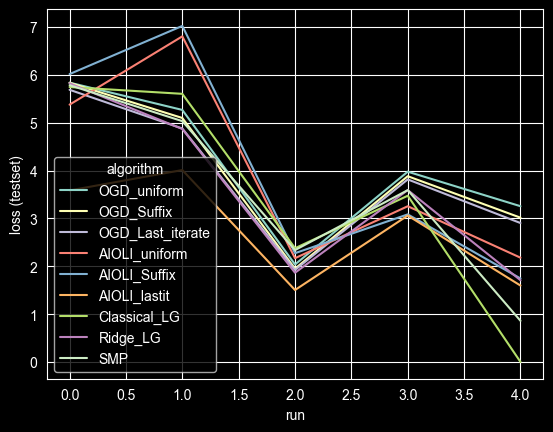

In [304]:
plot_results(well_specified_unbalanced_result)

In [278]:
high_dimensional_unbalanced = SimulationConfig(
    runs = 10,
    n = 20,
    d = 25,
    betas= bs_hd_unbalanced,
    x_means= xs_hd_unbalanced
)

high_dimensional_unbalanced_result = run_simulation(high_dimensional_unbalanced)
print_results(high_dimensional_unbalanced_result)


Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished
Run 5 finished
Run 6 finished
Run 7 finished
Run 8 finished
Run 9 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.434582,273.293704,9.667956,"[27.424, 6.982, -17.109, 13.417, 5.075, -2.219..."
Classical_LG,0.002755,0.000404,NaN,"[0.929, 0.339, -0.495, 0.324, 0.325, -0.14, -0..."
OGD_Last_iterate,NaN,8.188707,NaN,"[0.159, 0.027, -0.079, 0.108, 0.119, 0.029, -0..."
OGD_Suffix,NaN,6.836063,NaN,"[0.13, 0.01, -0.072, 0.1, 0.112, 0.029, -0.094..."
OGD_uniform,0.000210,16.198872,27.543112,"[0.103, -0.011, -0.04, 0.045, 0.101, 0.087, -0..."
Ridge_LG,0.003261,0.301660,NaN,"[0.296, 0.115, -0.161, 0.124, 0.085, -0.036, -..."


,loss (testset)
algorithm,
AIOLI_Suffix,4.122804
AIOLI_lastit,4.097022
AIOLI_uniform,4.137948
Classical_LG,6.711458
OGD_Last_iterate,4.956106
OGD_Suffix,4.078144
OGD_uniform,8.535293
Ridge_LG,3.189967
SMP,4.158882


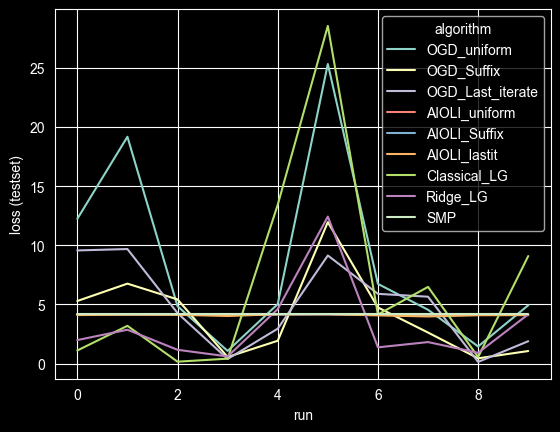

In [305]:
plot_results(high_dimensional_unbalanced_result)

In [279]:
high_dimensionality_unbalanced = SimulationConfig(
    runs = 5,
    n = 50,
    d = 25,
    betas= bs_hd_unbalanced,
    x_means= xs_hd_unbalanced
)

high_dimensionality_unbalanced_result = run_simulation(high_dimensionality_unbalanced)
print_results(high_dimensionality_unbalanced_result)


Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,3.789523,935.216716,23.063299,"[33.68, 41.479, -23.723, 33.685, 18.609, -21.1..."
Classical_LG,0.002764,0.001258,NaN,"[1.303, 0.934, -1.209, 0.882, 0.124, -0.133, -..."
OGD_Last_iterate,NaN,16.867174,NaN,"[0.229, 0.038, -0.173, 0.123, 0.116, 0.022, -0..."
OGD_Suffix,NaN,16.517556,NaN,"[0.204, 0.03, -0.141, 0.13, 0.146, 0.04, -0.11..."
OGD_uniform,0.000389,25.635619,46.383712,"[0.168, 0.02, -0.082, 0.11, 0.139, 0.051, -0.1..."
Ridge_LG,0.003526,0.939624,NaN,"[0.353, 0.237, -0.345, 0.217, 0.062, -0.084, -..."


,loss (testset)
algorithm,
AIOLI_Suffix,9.378806
AIOLI_lastit,8.527481
AIOLI_uniform,9.775116
Classical_LG,18.727080
OGD_Last_iterate,6.948622
OGD_Suffix,7.733839
OGD_uniform,12.115595
Ridge_LG,6.346334
SMP,10.397206


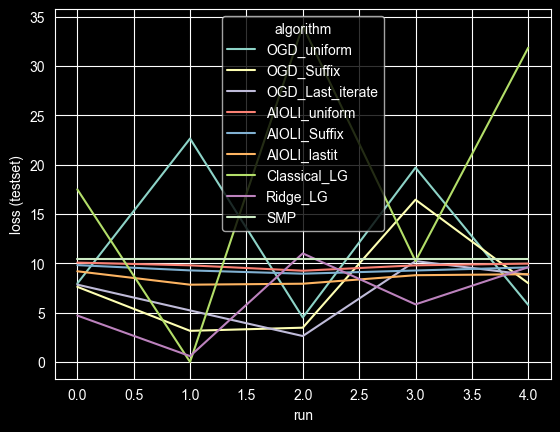

In [306]:
plot_results(high_dimensionality_unbalanced_result)

In [280]:
sinusoidal_unbalanced = SimulationConfig(
    runs = 10,
    n = 100,
    d = 3,
    betas= bs_unbalanced,
    x_means= xs_unbalanced,
    sinusoidal = True
)

sinusoidal_unbalanced_result = run_simulation(sinusoidal_unbalanced)
print_results(sinusoidal_unbalanced_result)

Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished
Run 5 finished
Run 6 finished
Run 7 finished
Run 8 finished
Run 9 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.193446,700.209007,261.395411,"[4.131, -4.088, 0.043]"
Classical_LG,0.001378,48.061735,NaN,"[-0.026, 0.029, 0.003]"
OGD_Last_iterate,NaN,52.169603,NaN,"[0.118, -0.144, -0.026]"
OGD_Suffix,NaN,50.643602,NaN,"[0.133, -0.153, -0.021]"
OGD_uniform,0.001007,51.402762,69.148536,"[0.159, -0.178, -0.019]"
Ridge_LG,0.001248,48.062195,NaN,"[-0.026, 0.028, 0.003]"


,loss (testset)
algorithm,
AIOLI_Suffix,39.213544
AIOLI_lastit,58.957092
AIOLI_uniform,41.583555
Classical_LG,20.894697
OGD_Last_iterate,22.148009
OGD_Suffix,22.794816
OGD_uniform,22.837429
Ridge_LG,20.887863
SMP,20.897742


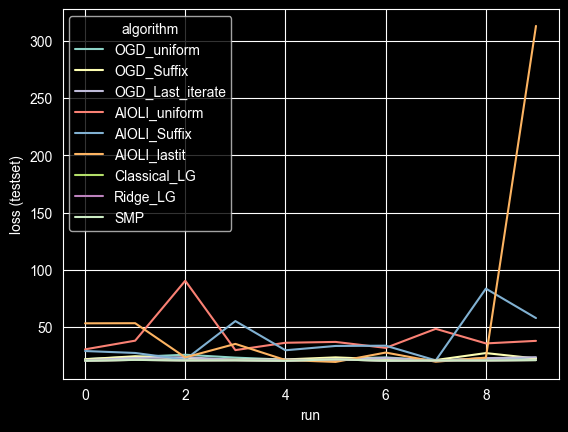

In [307]:
plot_results(sinusoidal_unbalanced_result)

## Graphing different data generating functions

In [281]:
# print(np.inner([1.5, 1.6, 0.7],[1.2, -0.9, -0.4]))
# bs_balanced = [2,0.1,-4.2]
# xs_balanced = [2,2,1]
# print(np.inner(bs_balanced,xs_balanced))

In [282]:
# x_s = generate_x(100,d = 3, means = [0.5, 0.8, 0.4], correlated = False)
# betas_s = [1.2, 0.9, 0.4]
# y_s = generate_y(100,x_s,betas_s)
# # p_s = [sig(dot) for dot in np.inner(x_s,betas_s)]
# # print(np.std(p_s))
# # print(np.mean(p_s))
# pd.Series(y_s).value_counts()

In [283]:
# y_s = generate_y(100,x_s,betas_s, enrique = False)

In [284]:
# for i in range(x_s.shape[1]):
#     sns.scatterplot(x = range(len(x_s[:,i])), y = [sig(np.inner(x,betas_s)) for x in x_s] )
#     plt.title(f"P(Y=1) over x{i}")
#     plt.show()

In [285]:
# i = 0
# [np.inner(x,betas_s) for x in x_s]


In [286]:


# sig(np.inner(x_s[4],betas_s))
#y_s = generate_y(n = 100,x = x_s, betas = betas_s)

#sns.scatterplot(x = x_s[:,0].flatten(), y = y_s)

In [287]:

# sns.lineplot(x = x_s[:,1].flatten(), y = y_s)

In [288]:
# sns.lineplot(x = x_s[:,2].flatten(), y = y_s)

In [289]:
# x_s[:,0].flatten()

In [290]:

# Data
# y = np.array([1,1,1,1,1,1,1,1,1])
# X = np.array([
#     [1,3,2],
#     [2,3,6],
#     [3,1,4],
#     [1,0,2],
#     [0,1,1],
#     [2,2,2],
#     [3,3,1],
#     [1,1,1],
#     [2,3,1]
# ])
#
# # Negative log-likelihood (sigmoid applied inline)
# def neg_loglik(beta):
#     z = X @ beta
#     p = 1 / (1 + np.exp(-z))          # sigmoid inline
#     #p = np.clip(p, 1e-12, 1 - 1e-12)  # numerical stability
#     return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
#
# # Initial guess
# beta0 = np.zeros(X.shape[1])
#
# # Optimize
# res = minimize(neg_loglik, beta0, method="BFGS")
#
# print("Optimal beta:", res.x)
# print("Converged:", res.success)
# print("Final negative log-likelihood:", res.fun)


### Check AIOLI convergence

In [291]:
#round((final_results[final_results["algorithm"] == "AIOLI_uniform"]["convergence"].mean() * 100 / n).item(),2)

In [292]:
#round((final_results[final_results["algorithm"] == "AIOLI_uniform"]["minimizer_gradient"].mean() * 100 / n).item(),2)

# Ignore from here on, it's simply code to test some functions/debugging

## Tests

In [293]:
#etas = np.array([1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3)])
#xt = np.array([1,2,3])
#betas = np.array([[2,2,5],[1,1,3],[4,5,6]])
#reg_lambda = 0.3
#gradients = np.array([[2,2,5],[1,1,3],[4,5,6]])
#b = np.array([1,2,3])
#sum_loss = 5


#(sum(etas)/2)*np.inner((b-betas[2]),gradients[2])*np.inner(gradients[2],(b-betas[2]))
#np.linalg.norm(etas)


In [294]:
#diff = b - betas
#inner_prod = np.sum(gradients * diff,axis = 1)
#np.sum(np.sum(etas)/2 * inner_prod**2)

In [295]:
# x0 = np.array([0,0,0])

#res = minimize(parameter_function_AIOLI, x0, method = "L-BFGS-B", args=(xt, reg_lambda, sum_loss,first_sum, etas_gradients))
#parameter_function_AIOLI(x0, xt, betas, etas, reg_lambda, sum_loss,gradients)
#res.x

In [296]:
# diff = b - betas
# gs_bs = np.sum(gradients * diff,axis = 1)
# quadratic = np.sum(np.sum(etas)/2 * gs_bs**2)
#
# l_hat = sum_loss + np.sum(gs_bs) + quadratic
#
# l_hat + np.log(1+np.exp(np.inner(b,xt))) + np.log(1+np.exp(np.inner(-b,xt))) + reg_lambda*np.linalg.norm(b)

## Generate data

In [297]:
# n = 1000
#
# mean = [20, 5, 2]
# cov = [[1, 0, 0], [0, 3, 0], [0,0,2]]  # diagonal covariance
# d = np.shape(cov)[1]
# y = np.random.binomial(n=1, p=0.3, size=n)
#
# x1, x2, x3 = np.random.multivariate_normal(mean, cov, size = n).T
# plt.plot(x1, x2, 'x')
# plt.axis('equal')
# plt.show()
#
# plt.plot(x1, x3, 'x')
# plt.axis('equal')
# plt.show()


In [298]:
# x = np.random.multivariate_normal(mean, cov, size = n)
# sns.countplot(x=y)
# plt.show()


In [299]:
# np.log(1000)

## OTB conversion proof tests

In [300]:
# weights = np.array([0.3,0.7])
# values = np.array([2,3])
#
# print(np.sum(values))
# print(np.sum(weights*values))